In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import h5py
import json
from scipy.stats import linregress
from scipy.interpolate import interp1d
import os
import glob
import sys


sys.path.append('/homes/dfs1/Refltools')
import LARIAT

from NEXAFS import load_spectrum_data, plot_spectra
from NEXAFS_BuildingBlock import simulate_nexafs_spectrum, plot_nexafs_fit, plot_simulated_nexafs_spectrum, fit_nexafs_spectrum, plot_fit_results, print_fit_results, generate_fitted_params_from_results

# Load Data

In [2]:
Polystyrene=load_spectrum_data('/homes/dfs1/Refltools/Workflow Examples/PolymerRefs_NEXAFSData/polystyrene_processed.csv')
# Poly2vinylpyridine=load_spectrum_data('/homes/dfs1/LARIAT/Polymer_Ref/Sept/poly2vinylpyridine_processed.csv')
# Poly4tertbutylstyrene=load_spectrum_data('/homes/dfs1/LARIAT/Polymer_Ref/Sept/poly4tertbutylstyrene_processed.csv')



# Polystyrene Fit
## Sept

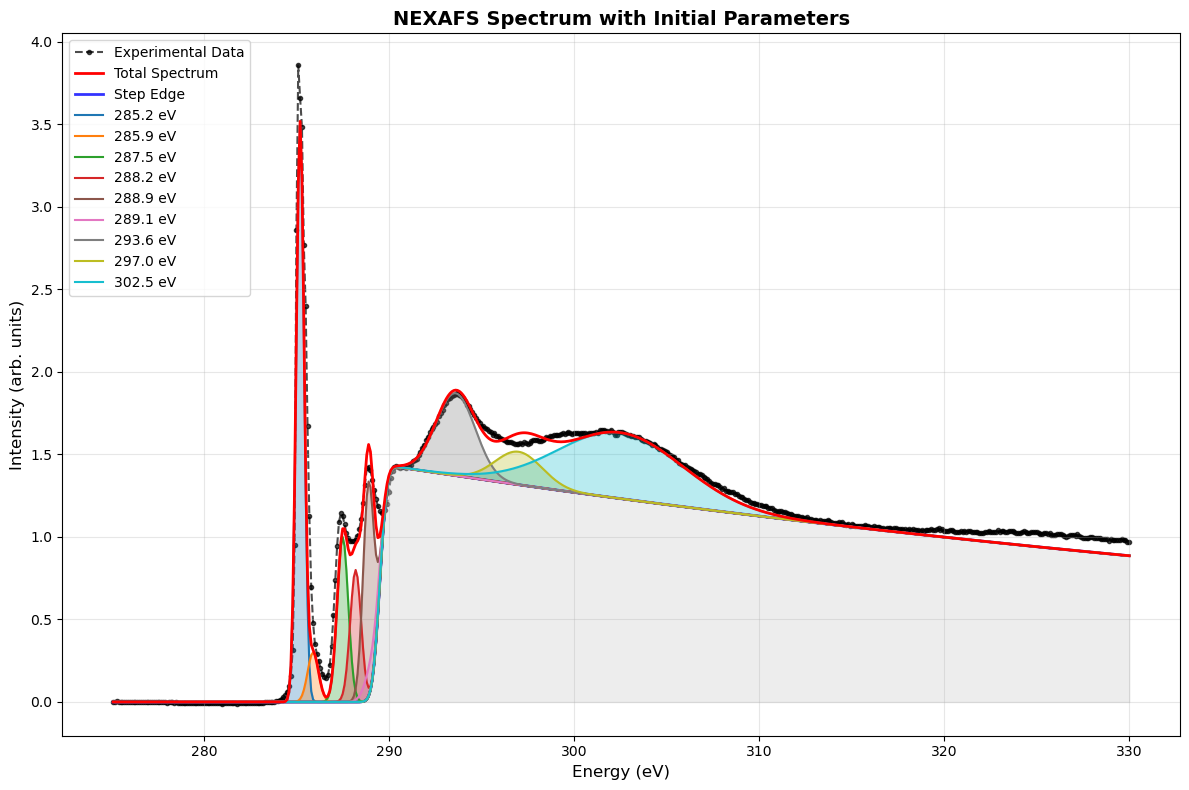

In [ ]:


peak_params_polystyrene= {
    "peak_1_energy": 285.2, "peak_1_energy_bounds": (285., 285.4, False), "peak_1_width": 0.5,"peak_1_width_bounds": (0.4, 1, True),"peak_1_height": 3.5,"peak_1_height_bounds": (3, 4, True), 
    "peak_2_energy": 285.9, "peak_2_energy_bounds": (285.7, 286.1, False), "peak_2_width": 0.7,"peak_2_width_bounds": (0.4, 1.2, True),"peak_2_height": 0.3,"peak_2_height_bounds": (0.1, 0.6, True), 
    "peak_3_energy": 287.5, "peak_3_energy_bounds": (287.3, 287.6, False), "peak_3_width": 0.7,"peak_3_width_bounds": (0.4, 1, True),"peak_3_height": 1,"peak_3_height_bounds": (0.3, 1.3, True),
    "peak_4_energy": 288.2, "peak_4_energy_bounds": (288., 288.5, False), "peak_4_width": 0.7,"peak_4_width_bounds": (0.4, 1, True),"peak_4_height": 0.8,"peak_4_height_bounds": (0.4, 1, True), 
    "peak_5_energy": 288.9, "peak_5_energy_bounds": (288.6, 289.2, False), "peak_5_width": 0.7,"peak_5_width_bounds": (0.4, 1.2, True),"peak_5_height": 1.3,"peak_5_height_bounds": (0.5, 1.9, True), 
    "peak_6_energy": 289.1, "peak_6_energy_bounds": (289, 289.2, True), "peak_6_width": .9,"peak_6_width_bounds": (0.4, 1.2, True),"peak_6_height": 0.2,"peak_6_height_bounds": (0.1, 1.9, True), 
    "peak_7_energy": 293.6, "peak_7_energy_bounds": (293.2, 293.9, True), "peak_7_width": 2.5,"peak_7_width_bounds": (2, 4.5, True),"peak_7_height": 0.5,"peak_7_height_bounds": (0.4, 1, True),  
    "peak_8_energy": 297, "peak_8_energy_bounds": (296, 300, True), "peak_8_width": 3,"peak_8_width_bounds": (2.8, 5, True),"peak_8_height": 0.2,"peak_8_height_bounds": (0.1, 0.8, True), 
    "peak_9_energy": 302.5, "peak_9_energy_bounds": (300, 305, True), "peak_9_width": 8,"peak_9_width_bounds": (6, 10, True),"peak_9_height": 0.4,"peak_9_height_bounds": (0.1, 0.8, True),  
}

#    

edge_params_polystyrene = {
    "location": 289.5,
    "height": 1.43,
    "width": 0.6,
    "decay": 0.012
}

baseline=0

spectrum = simulate_nexafs_spectrum(data=Polystyrene, peak_params=peak_params_polystyrene, edge_params=edge_params_polystyrene, baseline=baseline, plot=True)



Experimental data: 550 points, energy spacing: 0.100 eV
Fitting completed successfully using experimental energy axis (550 points)
FIT RESULTS SUMMARY
Fitted Baseline: 0.0

Peak   Energy (eV)                    Width                          Intensity                     
#      Lower  Fitted Upper  Lower  Fitted Upper  Lower  Fitted Upper 
------------------------------------------------------------------------------------------------------------------------
1       285.0  285.2  285.4    0.4    0.5    1.0    3.0    3.8    4.0
2       285.7  285.9  286.1    0.4    0.9    1.2    0.1    0.6    0.6
3       287.3  287.5  287.6    0.4    0.9    1.0    0.3    1.2    1.3
4       288.0  288.2  288.5    0.4    0.6    1.0    0.4    0.5    1.0
5       288.6  288.9  289.2    0.4    0.9    1.2    0.5    1.3    1.9
6       289.0  289.0  289.2    0.4    0.8    1.2    0.1    0.1    1.9
7       293.2  293.5  293.9    2.0    2.5    4.5    0.4    0.4    1.0
8       296.0  296.0  300.0    2.8    4.0    5

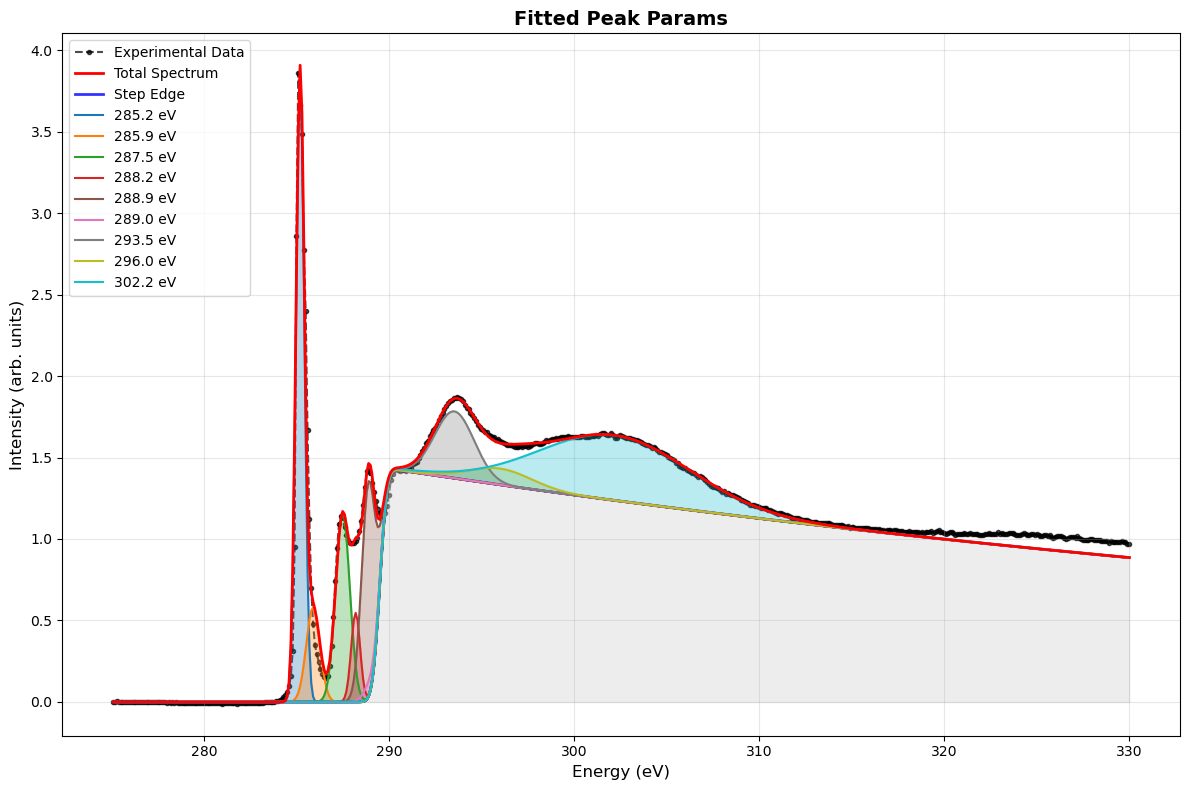

In [35]:
# Fit NEXAFS Spectrum

results_polystyrene = fit_nexafs_spectrum(
    data=Polystyrene,  # Or just pass file path as string
    peak_params=peak_params_polystyrene,
    edge_params=edge_params_polystyrene,
    baseline=baseline,
    algorithm='curve_fit',
    method='trf'

)

# Extract Fitted Peak and Edge Parameters
fitted_peak_params_polystyrene=results_polystyrene['fitted_peak_params']
fitted_edge_params_polystyrene=results_polystyrene['fitted_edge_params']

# Plot Fitted Results
fig = plot_simulated_nexafs_spectrum(
    Polystyrene[:,0], Polystyrene[:,1],
    fitted_peak_params_polystyrene,fitted_edge_params_polystyrene,
    title="Fitted Peak Params",
    baseline=baseline, 
)

# Print Fitted Results
print_fit_results(fitted_peak_params_polystyrene, fitted_edge_params_polystyrene, fitted_baseline=baseline)